In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping


features = pd.read_csv("hotels-europe_features.csv")
price = pd.read_csv("hotels-europe_price.csv")

df_full = pd.merge(features, price, on="hotel_id")
df_full = df_full.sort_values(["hotel_id", "year", "month"]).copy()


df_full = df_full[df_full["price"] < 2000].copy()


sequence_length = 5

tabular_cols = [
    "distance", "stars", "rating", "rating_reviewcount",
    "ratingta", "ratingta_count", "distance_alter",
    "city", "accommodation_type", "offer", "offer_cat",
    "year", "month", "weekend", "holiday", "nnights", "scarce_room"
]

rows = []

for hotel_id, group in df_full.groupby("hotel_id"):
    group = group.sort_values(["year", "month"]).reset_index(drop=True)

    if len(group) <= sequence_length:
        continue

    for i in range(len(group) - sequence_length):
        hist_prices = group.loc[i:i+sequence_length-1, "price"].values
        target_row = group.loc[i+sequence_length]

        row = {"target_price": target_row["price"]}

        for j in range(sequence_length):
            row[f"hist_price_{j+1}"] = hist_prices[j]

        for col in tabular_cols:
            row[col] = target_row[col]

        rows.append(row)

aligned_df = pd.DataFrame(rows)

print("aligned_df:", aligned_df.shape)


X_tab = aligned_df[tabular_cols].copy()
y = aligned_df["target_price"].values

X_tab = pd.get_dummies(
    X_tab,
    columns=["city", "accommodation_type", "offer_cat"],
    drop_first=True
)

X_tab = X_tab.fillna(X_tab.mean(numeric_only=True))


D:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


aligned_df: (53542, 23)


In [2]:
X_seq = aligned_df[[f"hist_price_{i+1}" for i in range(sequence_length)]].values
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

In [3]:
indices = np.arange(len(aligned_df))

train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_train_tab = X_tab.iloc[train_idx]
X_test_tab = X_tab.iloc[test_idx]

X_train_seq = X_seq[train_idx]
X_test_seq = X_seq[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]


In [4]:
#Linear Regression

lr = LinearRegression()
lr.fit(X_train_tab, y_train)

pred_lr = lr.predict(X_test_tab)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

In [5]:
#MLP
scaler_tab = StandardScaler()
X_train_tab_scaled = scaler_tab.fit_transform(X_train_tab)
X_test_tab_scaled = scaler_tab.transform(X_test_tab)

mlp = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
mlp.fit(X_train_tab_scaled, y_train)

pred_mlp = mlp.predict(X_test_tab_scaled)
rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))


D:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
#LSTM
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_seq_scaled = scaler_x.fit_transform(X_seq.reshape(-1,1)).reshape(X_seq.shape)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).flatten()

X_train_seq = X_seq_scaled[train_idx]
X_test_seq = X_seq_scaled[test_idx]

y_train_seq = y_scaled[train_idx]
y_test_seq = y_scaled[test_idx]

model_lstm = Sequential([
    LSTM(64, input_shape=(sequence_length,1)),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")

model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred_lstm_scaled = model_lstm.predict(X_test_seq).flatten()

pred_lstm = scaler_y.inverse_transform(pred_lstm_scaled.reshape(-1,1)).flatten()
y_test_real = scaler_y.inverse_transform(y_test_seq.reshape(-1,1)).flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_lstm))

D:\ProgramData\Anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 2/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9.6128e-04 - val_loss: 0.0010
Epoch 3/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9.4945e-04 - val_loss: 9.8696e-04
Epoch 4/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0010 - val_loss: 9.7522e-04
Epoch 5/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.1560e-04 - val_loss: 9.8593e-04
Epoch 6/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.9380e-04 - val_loss: 9.7365e-04
Epoch 7/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9.2186e-04 - val_loss: 9.6061e-04
Epoch 8/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9.2923e-04 - val_loss: 9.6467e-04
Epoch 9/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9.0607e-04 - val_loss: 9.8444e-04
Epoch 10/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8.8256e-04 - val_loss: 9.8225e-04
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [7]:
 Multimodal（MLP+LSTM）

input_tab = Input(shape=(X_train_tab_scaled.shape[1],))
x_tab = Dense(64, activation="relu")(input_tab)
x_tab = Dense(32, activation="relu")(x_tab)

input_seq = Input(shape=(sequence_length,1))
x_seq = LSTM(32)(input_seq)

combined = Concatenate()([x_tab, x_seq])
x = Dense(32, activation="relu")(combined)
output = Dense(1)(x)

model_fusion = Model(inputs=[input_tab, input_seq], outputs=output)
model_fusion.compile(optimizer="adam", loss="mse")

model_fusion.fit(
    [X_train_tab_scaled, X_train_seq],
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred_fusion = model_fusion.predict([X_test_tab_scaled, X_test_seq]).flatten()
rmse_mm = np.sqrt(mean_squared_error(y_test, pred_fusion))


Epoch 1/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 15239.1406 - val_loss: 7120.9409
Epoch 2/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 6561.2363 - val_loss: 6054.4644
Epoch 3/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5370.6118 - val_loss: 5335.7949
Epoch 4/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4874.4453 - val_loss: 4754.1812
Epoch 5/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4352.5059 - val_loss: 4261.5693
Epoch 6/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3880.3137 - val_loss: 3949.8120
Epoch 7/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3702.7400 - val_loss: 3709.8850
Epoch 8/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3315.4155 - val_loss: 3574.1121
Epoch 9/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2887.4326 - val_loss: 3526.2639
Epoch 10/10
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3115.7668 - val_loss: 3685.2954
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [8]:
print("\nRMSE Results:")
print("Linear:", rmse_lr)
print("MLP:", rmse_mlp)
print("LSTM:", rmse_lstm)
print("Multimodal:", rmse_mm)


RMSE Results:
Linear: 91.45476425795323
MLP: 72.61733100147299
LSTM: 58.144862026241086
Multimodal: 57.25711738769408


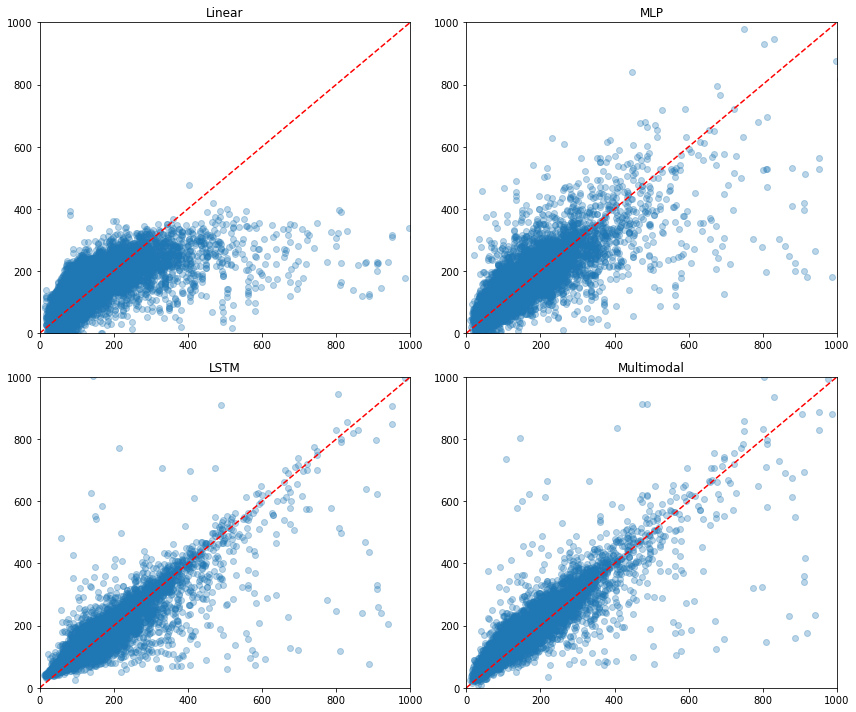

In [9]:
plt.figure(figsize=(12,10))

models = [
    ("Linear", y_test, pred_lr),
    ("MLP", y_test, pred_mlp),
    ("LSTM", y_test_real, pred_lstm),
    ("Multimodal", y_test, pred_fusion)
]

for i, (name, y_true, y_pred) in enumerate(models, 1):
    plt.subplot(2,2,i)
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot([0,1000],[0,1000],'r--')
    plt.title(name)
    plt.xlim(0,1000)
    plt.ylim(0,1000)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "MLP",
        "LSTM",
        "Multimodal"
    ],
    "RMSE": [
        rmse_lr,
        rmse_mlp,
        rmse_lstm,
        rmse_mm
    ]
})

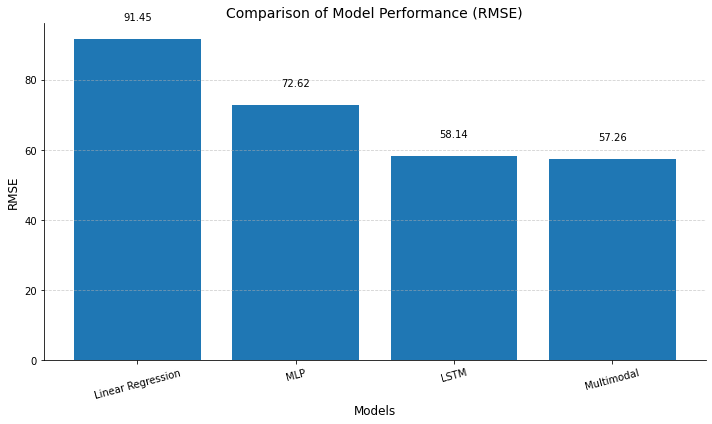

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)


for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 5, 
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Models", fontsize=12)
plt.ylabel("RMSE", fontsize=12)

plt.title("Comparison of Model Performance (RMSE)", fontsize=14)

plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.6)


plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

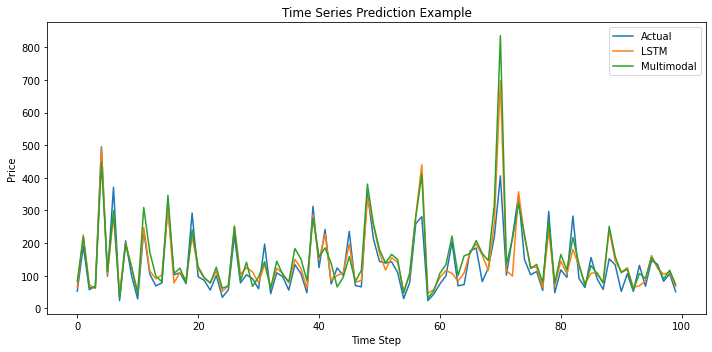

In [12]:
plt.figure(figsize=(10,5))

plt.plot(y_test_real[:100], label="Actual")
plt.plot(pred_lstm[:100], label="LSTM")
plt.plot(pred_fusion[:100], label="Multimodal")

plt.legend()
plt.title("Time Series Prediction Example")
plt.xlabel("Time Step")
plt.ylabel("Price")

plt.tight_layout()
plt.show()